Samples included: ['E1', 'E2', 'E3', 'E4']


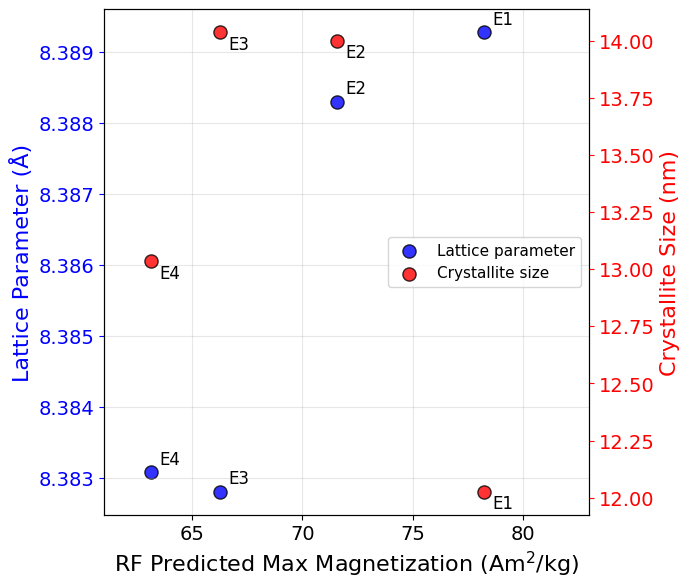

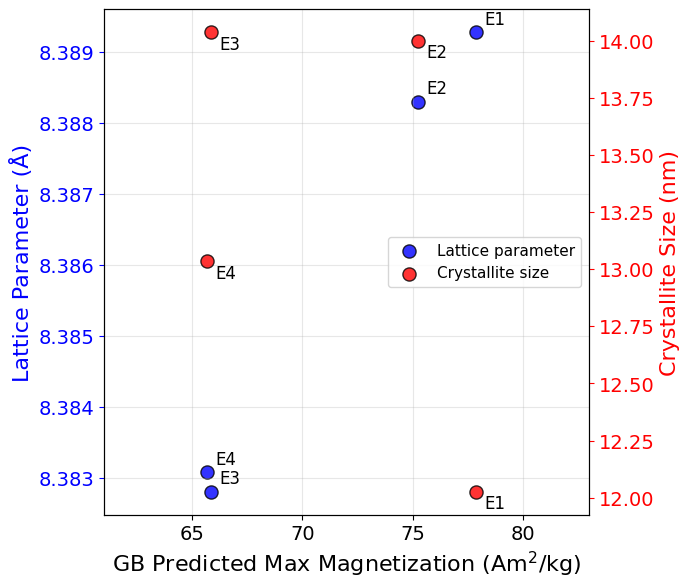

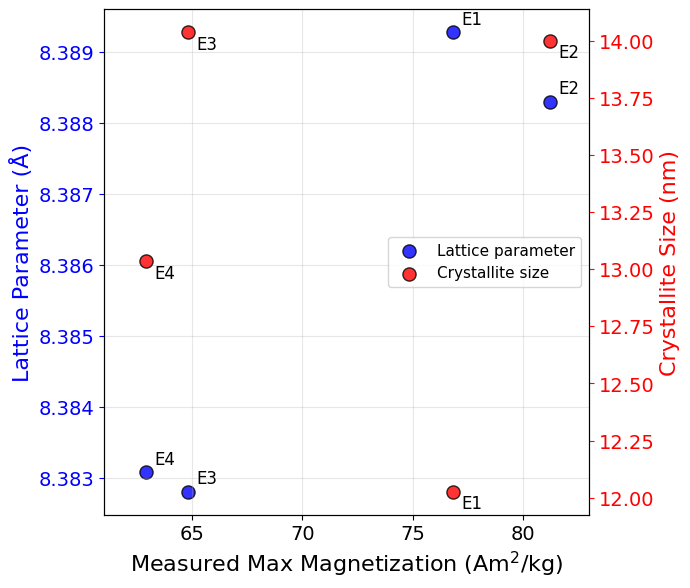

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# User inputs
# =========================
csv_dir = r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names"
csv_filename = "extracted_XRD_values_E1_E2_E3_E4_Bruker_processed_and_bg_sub.csv"
csv_path = os.path.join(csv_dir, csv_filename)

samples_to_plot = ["E1", "E2", "E3", "E4"]


# Optional x-axis limits
xlim_predicted = (61, 83)
xlim_gb_predicted = (61, 83)
xlim_measured = (61, 83)

# =========================
# Load and clean data
# =========================
df = pd.read_csv(csv_path)

df.columns = [c.strip() for c in df.columns]
df["sample name"] = df["sample name"].astype(str).str.strip()


for col in [
    "lattice parameter",
    "crystallite size",
    "measure magnetization",
    "predicted magnetization",
    "GB predicted magnetization"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

plot_df = df[df["sample name"].isin(samples_to_plot)].copy()

print("Samples included:", plot_df["sample name"].tolist())

# =========================
# Helper function
# =========================
def make_dual_axis_plot(df_in, x_col, x_label, xlim=None):
    dual_df = df_in.dropna(subset=[x_col]).copy()
    lat_df = dual_df.dropna(subset=["lattice parameter"]).copy()
    size_df = dual_df.dropna(subset=["crystallite size"]).copy()

    fig, ax1 = plt.subplots(figsize=(7, 6))
    ax2 = ax1.twinx()

    # Left axis: lattice parameter
    ax1.scatter(
        lat_df[x_col],
        lat_df["lattice parameter"],
        c="b",
        alpha=0.8,
        edgecolor="k",
        s=90,
        label="Lattice parameter"
    )

    for _, row in lat_df.iterrows():
        ax1.annotate(
            row["sample name"],
            (row[x_col], row["lattice parameter"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=12
        )

    # Right axis: crystallite size
    ax2.scatter(
        size_df[x_col],
        size_df["crystallite size"],
        c="r",
        alpha=0.8,
        edgecolor="k",
        s=90,
        label="Crystallite size"
    )

    for _, row in size_df.iterrows():
        ax2.annotate(
            row["sample name"],
            (row[x_col], row["crystallite size"]),
            xytext=(6, -12),
            textcoords="offset points",
            fontsize=12
        )

    ax1.set_xlabel(x_label, fontsize=16)
    ax1.set_ylabel("Lattice Parameter (Å)", fontsize=16, color="b")
    ax2.set_ylabel("Crystallite Size (nm)", fontsize=16, color="r")

    ax1.tick_params(axis="x", labelsize=14)
    ax1.tick_params(axis="y", labelsize=14, colors="b")
    ax2.tick_params(axis="y", labelsize=14, colors="r")

    if xlim is not None:
        ax1.set_xlim(*xlim)

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        fontsize=11,
        frameon=True,
        loc="center right"
    )

    ax1.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

# =========================
# Plot 1: RF Predicted magnetization
# =========================
make_dual_axis_plot(
    plot_df,
    x_col="predicted magnetization",
    x_label="RF Predicted Max Magnetization (Am$^2$/kg)",
    xlim=xlim_predicted
)

# =========================
# Plot 2: GB Predicted magnetization
# =========================
make_dual_axis_plot(
    plot_df,
    x_col="GB predicted magnetization",
    x_label="GB Predicted Max Magnetization (Am$^2$/kg)",
    xlim=xlim_gb_predicted
)

# =========================
# Plot 3: Measured magnetization
# =========================
make_dual_axis_plot(
    plot_df,
    x_col="measure magnetization",
    x_label="Measured Max Magnetization (Am$^2$/kg)",
    xlim=xlim_measured
)